(692703, 78)
Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std'],
      dtype='str')
Precision: 0.20093896713615023
Recall: 0.011010321681864235
F1: 0.020876717057448493


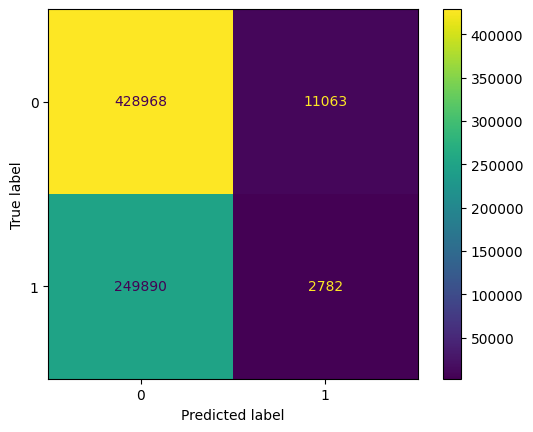

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.inspection import permutation_importance

df = pd.read_csv("../data/raw.csv", low_memory=False)
df.columns = df.columns.str.strip()
df.head()

# Select only numeric features
X = df.select_dtypes(include=["float64", "int64"])
X = X.fillna(0)

print(X.shape)
print(X.columns[:10])

# Create labels
y_true = df["Label"].apply(lambda x: 1 if x != "BENIGN" else 0)

# Train model
model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

model.fit(X)

# Predictions
y_pred = model.predict(X)
y_pred = [1 if x == -1 else 0 for x in y_pred]

# Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [2]:
# n_estimators = number of trees
# contamination = estimated anomaly percentage

model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

model.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


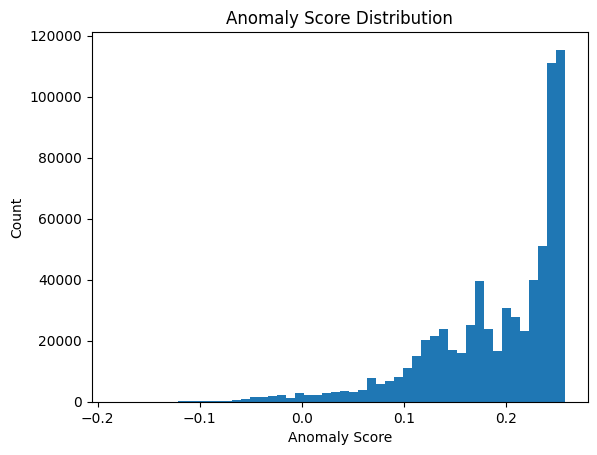

In [3]:
# decision_function() returns the anomaly score for each row.
# Higher value → more normal
# Lower value → more anomalous

anomaly_scores = model.decision_function(X)

plt.hist(anomaly_scores, bins=50)
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.title("Anomaly Score Distribution")
plt.show()

In [4]:
# This shape is typical for Isolation Forest with most traffic as normal and anomalies exist in the left tail

In [5]:
plt.savefig("../docs/anomaly-score-distribution.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

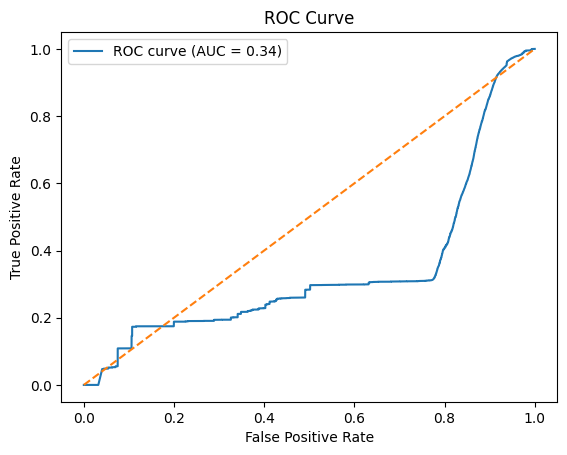

In [6]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, anomaly_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [7]:
# The ROC Curve AUC is 0.34 which shows 0.50 = random guessing and <0.50 = model performing poorly.
# This means the model is not separating attacks well. This is very common for raw CIC-IDS2017 data.

C:\Users\Bender\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
C:\Users\Bender\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2887: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
C:\Users\Bender\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Bender\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


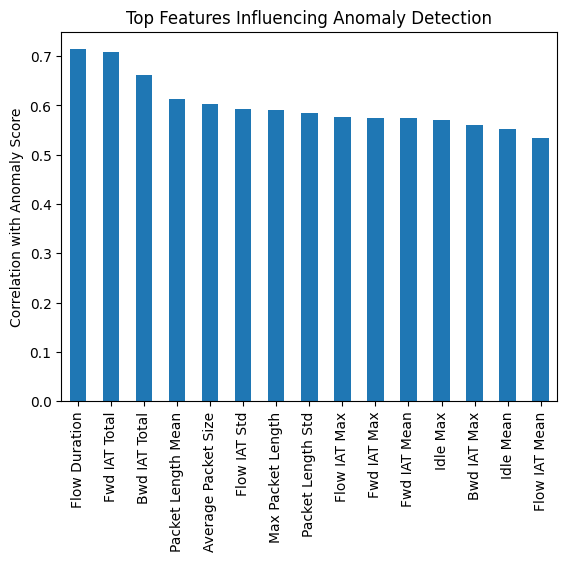

<Figure size 640x480 with 0 Axes>

In [8]:
# Compute anomaly scores
anomaly_scores = model.decision_function(X)

# Compute correlation between features and anomaly score
importance = pd.Series(
    [abs(pd.Series(X[col]).corr(pd.Series(anomaly_scores))) for col in X.columns],
    index=X.columns
).fillna(0)

# Plot top features
importance.nlargest(15).plot.bar()

plt.title("Top Features Influencing Anomaly Detection")
plt.ylabel("Correlation with Anomaly Score")
plt.show()

# Save chart
plt.savefig("../docs/feature-importance.png", bbox_inches="tight")

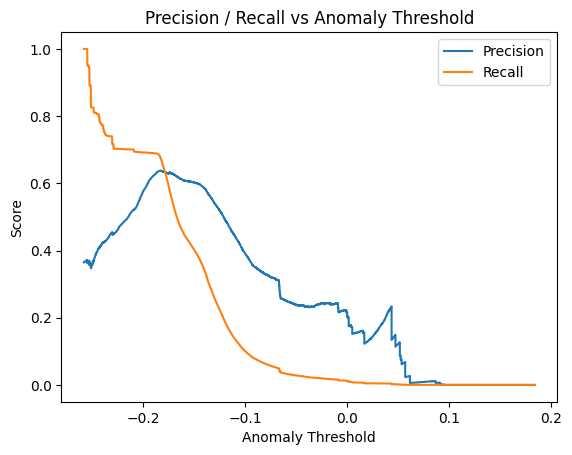

<Figure size 640x480 with 0 Axes>

In [9]:
# Isolation Forest anomaly scores
anomaly_scores = model.decision_function(X)

# Convert to anomaly likelihood (higher = more anomalous)
scores = -anomaly_scores

# Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_true, scores)

# Plot precision and recall vs threshold
plt.figure()

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Anomaly Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall vs Anomaly Threshold")

plt.legend()
plt.show()

# Save chart
plt.savefig("../docs/precision-recall-threshold.png", bbox_inches="tight")

#Precision   ↑ as threshold increases
#Recall      ↓ as threshold increases